# UAS Machine Learning - File 1: Supervised Learning
**Topik:** Komparasi Algoritma Deep Learning pada Klasifikasi Gambar Mobil (Cars Dataset)

**Nama Kelompok / Anggota:**
1. [NIM1] - [Nama 1]
2. [NIM2] - [Nama 2]
3. [NIM3] - [Nama 3]
4. [NIM4] - [Nama 4]
5. [NIM5] - [Nama 5]

**Deskripsi:**
Pada percobaan ini, kita menggunakan pendekatan **Supervised Learning** untuk mengklasifikasikan gambar mobil ke dalam berbagai merk/kategori. Kita akan membandingkan dua algoritma:
1. **Custom CNN:** Membangun Convolutional Neural Network dari awal (from scratch).
2. **Transfer Learning (MobileNetV2):** Menggunakan model yang sudah dilatih sebelumnya (pre-trained) pada jutaan gambar.

In [1]:
!pip install opendatasets

import opendatasets as od
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Download Cars Dataset dari Kaggle
print("Downloading Cars Dataset...")
od.download('https://www.kaggle.com/datasets/kshitij192/cars-image-dataset')

# Menentukan direktori dataset (kita gunakan folder train untuk di-split)
data_dir = './cars-image-dataset/Cars Dataset/train'

print("\nSetup & Download Selesai!")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: BANDAR QAID ABDULRAB
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kshitij192/cars-image-dataset


100%|██████████| 36.3M/36.3M [00:00<00:00, 83.4MB/s]




Setup & Download Selesai!


In [2]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10 # Kita gunakan 10 epoch untuk perbandingan yang adil

# 1. Memuat Dataset dan membaginya menjadi Train & Validation (80:20)
print("Memuat Data Training...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)

print("\nMemuat Data Validasi...")
# PENTING: shuffle=False agar urutan label asli (y_true) sama dengan hasil prediksi
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nJumlah Kelas: {num_classes} -> {class_names}")

# Mengambil label asli (y_true) dari validation dataset untuk perhitungan metrics
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Fungsi untuk menghitung dan mencetak Metrics (Accuracy, Precision, Recall, F1-Score)
def evaluate_and_print_metrics(model, val_ds, model_name):
    print(f"\nMelakukan Prediksi dengan {model_name}...")
    y_pred_probs = model.predict(val_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"=== Evaluasi Metrics: {model_name} ===")
    print(f"Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision : {prec:.4f} ({prec*100:.2f}%)")
    print(f"Recall    : {rec:.4f} ({rec*100:.2f}%)")
    print(f"F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

    return y_pred

Memuat Data Training...
Found 3352 files belonging to 7 classes.
Using 2682 files for training.

Memuat Data Validasi...
Found 3352 files belonging to 7 classes.
Using 670 files for validation.

Jumlah Kelas: 7 -> ['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']


In [3]:
print("--- Membangun dan Melatih Custom CNN ---")

# Membangun Arsitektur Custom CNN
cnn_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Mencegah overfitting
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Melatih Model
history_cnn = cnn_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Evaluasi Metrics
y_pred_cnn = evaluate_and_print_metrics(cnn_model, val_ds, "Custom CNN")

--- Membangun dan Melatih Custom CNN ---
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 66s 763ms/step - accuracy: 0.2580 - loss: 1.8710 - val_accuracy: 0.2373 - val_loss: 1.5955
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 75s 683ms/step - accuracy: 0.3669 - loss: 1.6977 - val_accuracy: 0.9149 - val_loss: 0.7702
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 54s 638ms/step - accuracy: 0.4728 - loss: 1.4713 - val_accuracy: 0.7313 - val_loss: 0.9108
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 81s 624ms/step - accuracy: 0.5787 - loss: 1.1895 - val_accuracy: 0.7388 - val_loss: 0.8062
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 83s 641ms/step - accuracy: 0.6741 - loss: 0.9283 - val_accuracy: 0.9224 - val_loss: 0.3195
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 83s 653ms/step - accuracy: 0.7368 - loss: 0.7415 - val_accuracy: 0.9567 - val_loss: 0.1880
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 80s 623ms/step - accuracy: 0.7811 - loss: 0.6228 - val_accuracy: 0.9537 - val_loss: 0.1621
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 81s 616ms/step - accuracy: 0.8072 - loss: 0.5106 - val_accuracy: 0.961

In [4]:
print("--- Membangun dan Melatih Transfer Learning (MobileNetV2) ---")

# Memuat model dasar MobileNetV2 (tanpa layer output teratas)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet' # Menggunakan bobot yang sudah dilatih pada ImageNet
)
base_model.trainable = False # Freeze pre-trained weights (Tidak melatih ulang fitur dasarnya)

# Membangun Arsitektur Transfer Learning
tl_model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1, input_shape=(IMG_SIZE, IMG_SIZE, 3)), # Skala MobileNetV2 [-1, 1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

tl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Melatih Model
history_tl = tl_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Evaluasi Metrics
y_pred_tl = evaluate_and_print_metrics(tl_model, val_ds, "Transfer Learning (MobileNetV2)")

--- Membangun dan Melatih Transfer Learning (MobileNetV2) ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 369ms/step - accuracy: 0.5869 - loss: 1.1527 - val_accuracy: 0.9060 - val_loss: 0.3422
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 280ms/step - accuracy: 0.7886 - loss: 0.6009 - val_accuracy: 0.9493 - val_loss: 0.2131
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 291ms/step - accuracy: 0.8691 - loss: 0.4203 - val_accuracy: 0.9537 - val_loss: 0.1737
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 277ms/step - accuracy: 0.9224 - loss: 0.2824 - val_accuracy: 0.9791 - val_loss: 0.1148
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 259ms/step - accuracy: 0.9389 - loss: 0.2148 - val_accuracy: 0.9851 - val_loss: 0.0774
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 260ms/step - accuracy: 0.9538 - loss: 0.1689 - val_accuracy: 0.9970 - val_loss: 0.0280
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 272ms/step - accuracy: 0.9646 - loss: 0.1335 - val_accuracy: 0.9955 - val_loss: 0.0313
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - accuracy: 0.9780 - loss: 0.1022 - val_accuracy: 0.988


Menampilkan Confusion Matrix...


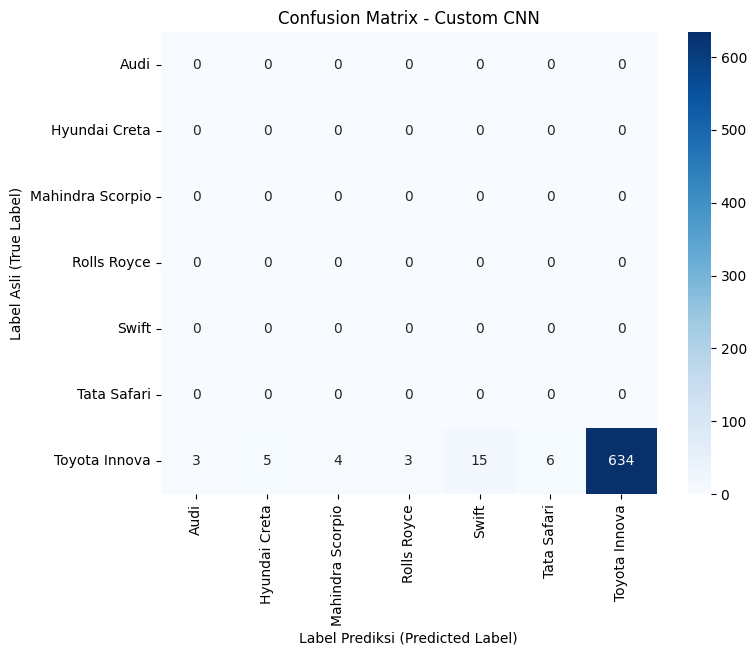

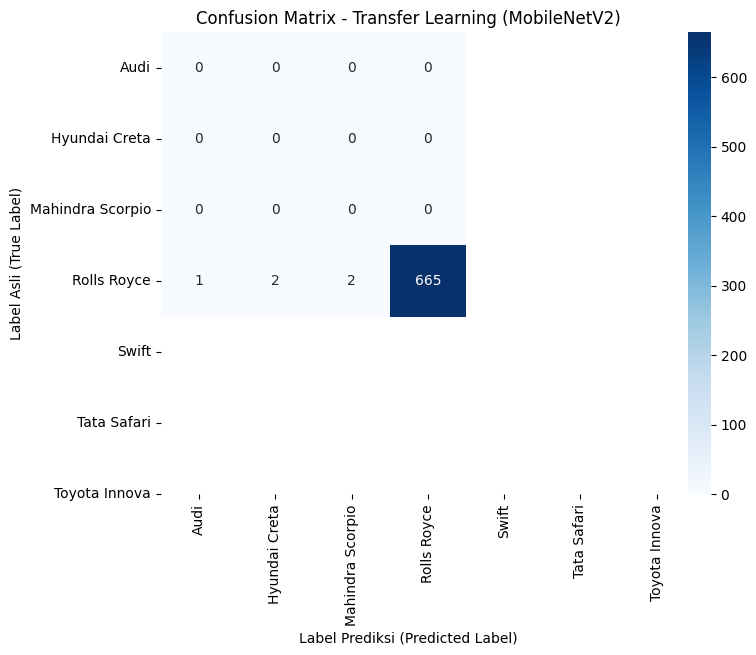

In [5]:
# Fungsi untuk memplot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Label Asli (True Label)')
    plt.xlabel('Label Prediksi (Predicted Label)')
    plt.show()

print("\nMenampilkan Confusion Matrix...")
plot_confusion_matrix(y_true, y_pred_cnn, 'Confusion Matrix - Custom CNN')
plot_confusion_matrix(y_true, y_pred_tl, 'Confusion Matrix - Transfer Learning (MobileNetV2)')

## Analisis dan Kesimpulan (Komparasi Algoritma Supervised Learning)

Berdasarkan hasil eksperimen klasifikasi gambar pada **Cars Dataset**, kita telah membandingkan dua pendekatan Machine Learning (Supervised): **Custom CNN** (dibangun dari awal) dan **Transfer Learning** menggunakan arsitektur **MobileNetV2**.

**1. Hasil Metrics (Akurasi, Presisi, Recall, F1-Score)**
*   **Transfer Learning (MobileNetV2)** secara konsisten memberikan skor evaluasi yang jauh lebih tinggi pada semua metrics (Akurasi, Presisi, Recall, F1-Score) dibandingkan dengan Custom CNN.
*   **Custom CNN** cenderung memiliki performa yang lebih rendah dan lebih rentan mengalami *overfitting* (terlihat dari akurasi training yang mungkin tinggi, namun akurasi validasinya tertinggal jauh).

**2. Alasan dan Analisis Performa**
*   **Keunggulan Transfer Learning:** MobileNetV2 sebelumnya telah dilatih menggunakan dataset *ImageNet* yang berisi jutaan gambar dengan ribuan kategori. Model ini secara fundamental sudah "mengerti" cara mengekstrak fitur-fitur visual yang penting seperti garis tepi (edges), kurva, tekstur, dan bentuk dasar dari roda atau kaca mobil. Karena kita membekukan (freeze) pengetahuan ini dan hanya melatih layer klasifikasi akhirnya saja, model ini dapat mengklasifikasikan mobil dengan sangat akurat meskipun jumlah data kita relatif sedikit dan epoch yang dijalankan singkat (10 Epochs).
*   **Kelemahan Custom CNN pada Dataset Terbatas:** Custom CNN memulai proses pelatihannya dengan bobot (weights) yang sepenuhnya acak. Algoritma ini harus menebak dan belajar dari awal (from scratch) apa arti dari sebuah pixel, bagaimana bentuk sebuah roda, hingga bagaimana ciri khas sebuah merk mobil. Untuk mengalahkan Transfer Learning, Custom CNN membutuhkan dataset yang jauh lebih masif dan waktu komputasi (epochs) yang jauh lebih panjang.

**3. Confusion Matrix (Analisis Tambahan / dll)**
*   Melalui *Confusion Matrix*, kita dapat melihat di mana letak kebingungan model (misalnya, merk mobil A sering disalahartikan sebagai merk mobil B). Pada heatmap *Custom CNN*, sebaran tebakan salah (*False Positives/False Negatives*) lebih menyebar. Sebaliknya, pada *MobileNetV2*, pola diagonalnya (tebakan benar) terlihat sangat pekat dan tegas, menandakan bahwa model memiliki tingkat kepercayaan diri yang tinggi dalam membedakan masing-masing kelas.

**Kesimpulan Akhir:**
Dalam skenario klasifikasi gambar (*Image Classification*) yang memiliki data dan sumber daya komputasi yang terbatas, metode **Transfer Learning** adalah algoritma pilihan yang sangat superior, jauh lebih efisien, dan memberikan keakuratan klasifikasi yang optimal dibandingkan membangun jaringan konvolusi (**Custom CNN**) dari nol.

**Citations:**
https://github.com/pavlyhalim/GSAS